In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
#import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

from cinplaAnalysis.utils import *

%matplotlib inline

In [2]:
from cinplaAnalysis.icsd import StandardCSD, DeltaiCSD, StepiCSD

In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [5]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=False,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-10,vmax=10)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [14]:
highRes = np.load('../noNoise/total.npy')#pd.read_pickle('0/pkls/eegL4_SSC.pkl').values # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

lfpIdx = np.arange(101) 

totalLFPHighRes = highRes[:,lfpIdx] # LFP, 20 um spacing
totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

objective = pd.read_pickle('0/pkls/eegL4_SSC.pkl').values#np.load('total.npy')
objective_100 = objective[:,:101]
objective_50 = objective[:,101:202]


In [29]:
eegs = np.load('EEGs.npy',allow_pickle=True).item()

In [43]:
e[1]

electrode,0,1,2,3,4,5,6,7,8,9,...,193,194,195,196,197,198,199,200,201,202
1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.001109,-0.001408,-0.001700,-0.002113,-0.002681,0.000950,-0.001183,-0.001222,-0.002120,-6.878172e-18
1501.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.001089,-0.001382,-0.001680,-0.002099,-0.002675,0.000956,-0.001184,-0.001222,-0.002120,-7.302800e-18
1502.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.001070,-0.001358,-0.001660,-0.002084,-0.002669,0.000962,-0.001184,-0.001222,-0.002120,-1.719689e-18
1503.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.001052,-0.001335,-0.001641,-0.002070,-0.002663,0.000967,-0.001184,-0.001222,-0.002120,-1.515294e-17
1504.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.001035,-0.001313,-0.001622,-0.002056,-0.002657,0.000971,-0.001184,-0.001222,-0.002120,-1.104864e-17
1505.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.001020,-0.001294,-0.001603,-0.002042,-0.002652,0.000975,-0.001184,-0.001222,-0.002120,7.778356e-18
1506.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.001006,-0.001275,-0.001585,-0.002029,-0.002647,0.000978,-0.001184,-0.001222,-0.002120,-2.025494e-17
1507.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000992,-0.001258,-0.001568,-0.002016,-0.002643,0.000981,-0.001184,-0.001222,-0.002120,2.847301e-18
1508.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000980,-0.001242,-0.001552,-0.002004,-0.002638,0.000983,-0.001184,-0.001222,-0.002120,-1.597589e-17
1509.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000968,-0.001227,-0.001537,-0.001992,-0.002634,0.000986,-0.001184,-0.001222,-0.002120,-3.430589e-18


In [33]:
np.max(np.load('total.npy'))

np.float32(3.0046127)

In [44]:
for e in eegs.items():
    print(np.max(e[1].values))

0.007889491
0.009162576
0.0016590644
0.009269527
0.005049836
1.8337613
0.46831936
0.012070971
0.43491086
0.009722443
1.3749841
0.05530081
1.3405974
0.016780235
2.0487077
3.1937594e-16
4.1473698e-17
1.5273153e-16
1.2256062
0.6177562
4.397901e-18
1.4172222e-16
1.2771902e-16
5.205695e-17
3.0335435e-15
2.1329016e-15
4.7846916e-14
6.5290147e-17
5.6844178e-15
4.7280564e-16
9.994032e-16
2.5499819e-15
3.887733e-17
7.773057e-17
3.921844e-15
5.273627e-17
5.8078406e-14
5.9116234e-15
2.5970757e-14
3.380932e-17
2.7639447e-14
7.784228e-15
6.0718752e-15
8.5109823e-16
7.0813606e-16
0.0056840596
2.9987156
0.01802454
1.1654694e-14
5.2135945e-15
1.1693106e-14
4.2918465e-15
4.1080536e-14
4.256897e-14
1.9972308e-14
0.0031286604
8.15279e-15
3.310509e-14
1.1566577e-14
0.0875589


In [24]:
np.max(pd.read_pickle('0/pkls/eegL5_TPC:A.pkl'))

np.float32(7.784228e-15)

In [15]:
### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)

for l in range(objective_disk_full_lowRes.shape[1]):
    if l == 0:
        objective_disk_full_lowRes[:,l] = objective_50[:,2*l]+.5*objective_50[:,2*l+1]
    elif l == objective_disk_full_lowRes.shape[1]-1:
        objective_disk_full_lowRes[:,l] = objective_50[:,2*l]+.5*objective_50[:,2*l-1]
    else:
        objective_disk_full_lowRes[:,l] = objective_50[:,2*l]+.5*objective_50[:,2*l-1]+.5*objective_50[:,2*l+1]

for l in range(objective_disk_half_lowRes.shape[1]):
    if l == 0:
        objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
    elif l == objective_disk_half_lowRes.shape[1]-1:
        objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
    else:
        objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]

for l in range(objective_disk_quarter_lowRes.shape[1]):
    if l == 0:
        objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
    elif l == objective_disk_quarter_lowRes.shape[1]-1:
        objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
    else:
        objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]


In [16]:
### Calculates iCSD and standard CSD

diam = 100E-6 * pq.m                              # [m]
sigma = 0.376 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
sigma_top = 0.376 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]

# Input dictionaries for each method

step_input_high = {
    'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
    'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':20E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam
}

step_input_low = {
    'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':40E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam
}

step_input_low_half = {
    'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':80E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam
}

step_input_low_quarter = {
    'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'h':160E-6 * pq.m ,
    'f_type' : 'gaussian',
    'f_order' : (3, 1),
    'diam': diam
}

std_input_high = {
    'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
    'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low = {
    'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low_half = {
    'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low_quarter = {
    'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}


icsd_high = StepiCSD(**step_input_high)
icsd_low = StepiCSD(**step_input_low)
icsd_low_half = StepiCSD(**step_input_low_half)
icsd_low_quarter = StepiCSD(**step_input_low_quarter)

icsd_high_std = StandardCSD(**std_input_high)
icsd_low_std = StandardCSD(**std_input_low)
icsd_low_half_std = StandardCSD(**std_input_low_half)
icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)
        

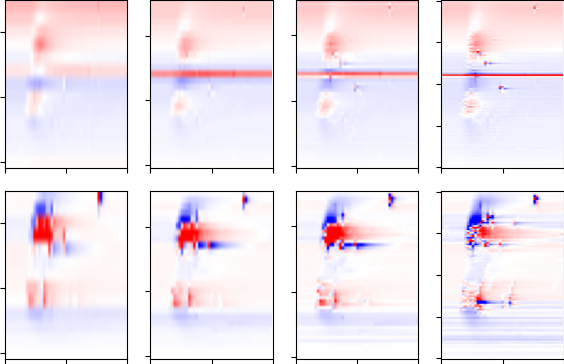

In [17]:
### Plots Figure 2a

fig, axes = plt.subplots(2,4,figsize=(6,4))

plotFig(axes[0][0],icsd_low_quarter.get_csd())
plotFig(axes[1][0],objective_disk_quarter_lowRes.T)

plotFig(axes[0][1],icsd_low_half.get_csd())
plotFig(axes[1][1],objective_disk_half_lowRes.T)

plotFig(axes[0][2],icsd_low.get_csd())
plotFig(axes[1][2],objective_disk_full_lowRes.T)

plotFig(axes[0][3],icsd_high.get_csd())
plotFig(axes[1][3],objective_100.T)

#plt.savefig('figures/csds.png',dpi=600)


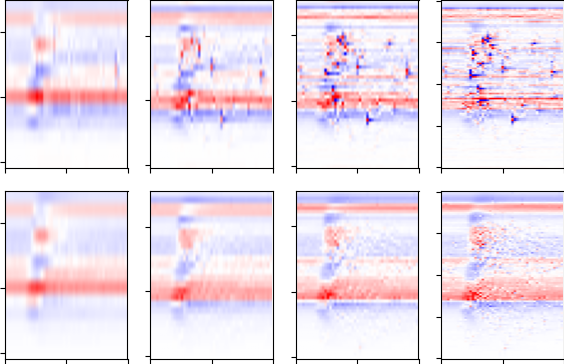

In [18]:
### Plots the equivalent of Figure 2a, but for standard CSD instead of iCSD. Not used in the paper

fig, axes = plt.subplots(2,4,figsize=(6,4))

plotFig(axes[0][0],icsd_low_quarter_std.get_csd())
plotFig(axes[1][0],objective_disk_quarter_lowRes.T)

plotFig(axes[0][1],icsd_low_half_std.get_csd())
plotFig(axes[1][1],objective_disk_half_lowRes.T)

plotFig(axes[0][2],icsd_low_std.get_csd())
plotFig(axes[1][2],objective_disk_full_lowRes.T)

plotFig(axes[0][3],icsd_high_std.get_csd())
plotFig(axes[1][3],objective_disk_full_highRes.T)

#plt.savefig('figures/csds_std.png',dpi=600)

In [20]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

correlations_high_stim = []
correlations_low_stim = []
correlations_low_half_stim = []
correlations_low_quarter_stim = []

for i in np.arange(1500,1550):
    correlations_high_stim.append(np.corrcoef(icsd_high.get_csd()[:,i],objective_disk_full_highRes.T[:,i])[0,1])
    correlations_low_stim.append(np.corrcoef(icsd_low.get_csd()[:,i],objective_disk_full_lowRes.T[:,i])[0,1])
    correlations_low_half_stim.append(np.corrcoef(icsd_low_half.get_csd()[:,i],objective_disk_half_lowRes.T[:,i])[0,1])
    correlations_low_quarter_stim.append(np.corrcoef(icsd_low_quarter.get_csd()[:,i],objective_disk_quarter_lowRes.T[:,i])[0,1])


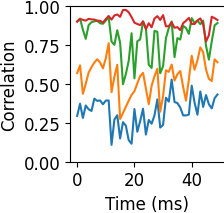

In [21]:
### Plots Figure 2b

plt.figure(figsize=(2.5,2.5))
plt.plot(correlations_high_stim,c='C0')
plt.plot(correlations_low_stim,c='C1')
plt.plot(correlations_low_half_stim,c='C2')
plt.plot(correlations_low_quarter_stim,c='C3')

plt.ylim([0,1])
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
# plt.savefig('figures/correlations.png',dpi=300)

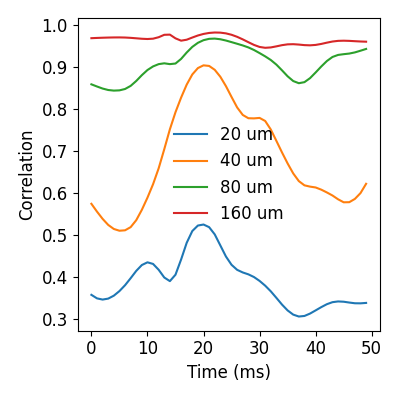

In [25]:
### Plots Figure 2b again, but with a legend

plt.figure(figsize=(4,4))
plt.plot(correlations_high_stim,c='C0',linestyle=None)
plt.plot(correlations_low_stim,c='C1',linestyle=None)
plt.plot(correlations_low_half_stim,c='C2',linestyle=None)
plt.plot(correlations_low_quarter_stim,c='C3',linestyle=None)

# plt.plot(correlations_high_rest,'--',c='C0')
# plt.plot(correlations_low_rest,'--',c='C1')
# plt.plot(correlations_low_half_rest,'--',c='C2')
# plt.plot(correlations_low_quarter_rest,'--',c='C3')

plt.legend(['20 um', '40 um','80 um','160 um'],framealpha=0)
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
plt.savefig('figures/correlations_legend.png',dpi=300)